# Saddle-Point Navigation — Evolution of the Step Rule

**6-robot pentagon-plus-center formation** estimating the gradient and Hessian of a scalar
field by exact quadratic least squares (6 readings, 6 unknowns), then stepping toward the
saddle. The estimator and formation are fixed throughout; **only the step rule changes.**

This notebook walks the step rule through five stages so the design evolution is visible:

1. **Newton** — $\Delta=-H^{-1}\nabla\sigma$. Converges to the saddle, but approaches along a
   straight ray: it does *not* preferentially collapse onto the trench first.
2. **Sign-decomposed (first order)** — $\text{step}=h\,\mathrm{sign}(\Delta)$. Reaches the
   trench fast, but the discontinuous switching **chatters** on the surface. This is a
   first-order sliding mode in the standard axis basis.
3. **Anisotropic Newton** — split the Newton step in the **Hessian eigenbasis** and damp the
   across-trench (positive-curvature) direction hard and the along-trench (negative-curvature)
   direction gently. Smooth, exponential snap to the trench, gentle climb. Reduces to plain
   Newton when the two gains are equal.
4. **Tanh sliding** — boundary-layer sliding mode: a saturated $\tanh$ reaching law on the
   across-trench surface (bounded, chatter-free reach speed) plus the same gentle climb.
5. **Adaptive eigen (self-tuning)** — apply the same $\tanh$ saturation to *each* Newton
   eigenstep with a single velocity cap $v_{\max}$. Far from the saddle it is a bounded
   constant-speed reach in every eigen-direction; near the saddle it relaxes to *pure Newton*
   (superlinear convergence). One physically-meaningful parameter, no gain tuning.

**Field:** log-sum-exp of two Gaussians at $(\pm2,0)$. Saddle at the origin, Hessian
$\approx\mathrm{diag}(3,-1)$ there. The **trench** is the line $x=0$: the positive-curvature
($+3$) direction is *across* the trench, the negative-curvature ($-1$) direction is *along* it.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Scalar field: log-sum-exp saddle

In [2]:
class ScalarField:
    """Soft-max (log-sum-exp) of two Gaussians at (-2,0) and (2,0). Saddle at the origin."""

    def __init__(self):
        self.g1_center = np.array([-2.0, 0.0])
        self.g2_center = np.array([ 2.0, 0.0])

    def evaluate(self, x, y):
        g1 = -((x + 2)**2 + y**2) / 2
        g2 = -((x - 2)**2 + y**2) / 2
        mx = np.maximum(g1, g2)
        return mx + np.log(np.exp(g1 - mx) + np.exp(g2 - mx))

    def plot_contour(self, ax, x_range=(-3, 3), y_range=(-3, 3), levels=25):
        x = np.linspace(*x_range, 240); y = np.linspace(*y_range, 240)
        X, Y = np.meshgrid(x, y); Z = self.evaluate(X, Y)
        cs = ax.contourf(X, Y, Z, levels=levels, cmap="viridis", alpha=0.55)
        ax.contour(X, Y, Z, levels=levels, colors="gray", linewidths=0.4, alpha=0.3)
        return cs

    def plot_surface(self, ax, x_range=(-3, 3), y_range=(-3, 3), grid_res=100):
        x = np.linspace(*x_range, grid_res); y = np.linspace(*y_range, grid_res)
        X, Y = np.meshgrid(x, y); Z = self.evaluate(X, Y)
        return ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.7, edgecolor="none")

## Pentagon + center formation

5 robots uniformly on a ring of radius $D$ at angles $\varphi_0+\tfrac{2\pi k}{5}$, plus 1 at
the center. Fixed orientation (no rotation control).

In [3]:
class PentagonFormation:
    """5 robots on a pentagon ring + 1 at the center."""

    def __init__(self, radius=0.2, base_angle=0.0):
        self.radius = radius
        self.base_angle = base_angle

    def robot_positions(self, centroid):
        centroid = np.asarray(centroid)
        angles = self.base_angle + 2 * np.pi * np.arange(5) / 5
        ring = centroid[None, :] + self.radius * np.column_stack([np.cos(angles), np.sin(angles)])
        return np.vstack([ring, centroid[None, :]])

    def relative_positions(self, centroid):
        return self.robot_positions(centroid) - np.asarray(centroid)[None, :]

## Quadratic estimator (exact 6×6 solve)

Basis $\varphi(\bar{\mathbf r})=[1,\,x,\,y,\,\tfrac{x^2}{2},\,xy,\,\tfrac{y^2}{2}]^T$.
Solving $\Phi\theta=\mathbf s$ gives the Taylor data at the center:
$\theta=[\sigma(c),\,\partial_x,\,\partial_y,\,H_{11},\,H_{12},\,H_{22}]^T$.

In [4]:
class QuadraticEstimator:
    """Fit a quadratic model from 6 readings; Hessian falls out of the coefficients."""

    @staticmethod
    def basis(rx, ry):
        return np.array([1, rx, ry, rx**2 / 2, rx * ry, ry**2 / 2], dtype=float)

    def fit(self, relative_positions, readings):
        Phi = np.array([self.basis(r[0], r[1]) for r in relative_positions])
        try:
            theta = np.linalg.solve(Phi, readings)
        except np.linalg.LinAlgError:
            theta = np.linalg.lstsq(Phi, readings, rcond=None)[0]
        return theta

    def extract_gradient(self, theta):
        return theta[1:3]

    def extract_hessian(self, theta):
        return np.array([[theta[3], theta[4]], [theta[4], theta[5]]])

## The trench, in Hessian eigen-coordinates

At a saddle the Hessian is **indefinite**: one positive eigenvalue and one negative. Eigh-decompose
$H=V\Lambda V^T$ with $\lambda_{\perp}>0$ (eigenvector $v_{\perp}$) and $\lambda_{\parallel}<0$
(eigenvector $v_{\parallel}$). Geometrically:

* $v_{\perp}$ (**positive** curvature) points *across* the trench — the convex walls.
* $v_{\parallel}$ (**negative** curvature) points *along* the trench — the floor that arcs over
  the saddle (a maximum along this direction).

So the trench direction is recovered from the **sign of the eigenvalue**, not its magnitude — and
not from a scalar like $\det H=\lambda_{\perp}\lambda_{\parallel}$, which tells you you are at a
saddle but discards the orientation entirely.

Decomposing the gradient $g=g_{\perp}v_{\perp}+g_{\parallel}v_{\parallel}$ (with
$g_i=v_i^{T}g$), the Newton step is
$$\Delta=-H^{-1}g=-\frac{g_{\perp}}{\lambda_{\perp}}v_{\perp}-\frac{g_{\parallel}}{\lambda_{\parallel}}v_{\parallel}.$$
Near the saddle $g\approx H r$, so the Newton sub-step in each eigen-direction is just
$-r_i$ — curvature is normalized away. Damping each sub-step with its own gain therefore sets a
**clean per-direction convergence rate** $r_i\leftarrow(1-\text{gain}_i)\,r_i$. That is the lever
the next two step rules pull.

In [5]:
def trench_frame(H):
    """Return (perp, along) eigendata of a symmetric 2x2 Hessian.

    perp  = (lambda>0, v): across-trench, convex walls
    along = (lambda<0, v): along-trench, the floor over the saddle
    Returns None if H is not a clean saddle (det >= 0 or a near-zero eigenvalue).
    """
    lam, V = np.linalg.eigh(H)              # ascending eigenvalues, orthonormal columns
    if lam[0] * lam[1] >= -1e-9 or np.min(np.abs(lam)) < 1e-9:
        return None
    ip = int(np.argmax(lam)); ia = int(np.argmin(lam))
    return (lam[ip], V[:, ip]), (lam[ia], V[:, ia])

## Step-rule family

All four steppers share one interface — `compute_step(gradient, hessian) -> step` — so they drop
straight into the same navigator. Swap the stepper, re-run.

### 1. Newton step  $\Delta=-H^{-1}\nabla\sigma$

The step that already works well: at a saddle, $H$ is indefinite and the step points toward the
critical point regardless of the gradient direction. Damped by `step_size`, magnitude clipped for
stability. Drawback: it approaches along a straight ray — no preferential snap onto the trench.

In [6]:
class NewtonStepper:
    """Damped Newton step toward the saddle."""

    def __init__(self, step_size=0.02, max_step=1.0):
        self.step_size = step_size
        self.max_step = max_step

    def compute_step(self, gradient, hessian):
        det = np.linalg.det(hessian)
        if abs(det) > 1e-10:
            delta = -np.linalg.solve(hessian, gradient)
        else:
            delta = -np.linalg.pinv(hessian) @ gradient
        n = np.linalg.norm(delta)
        if n > self.max_step:
            delta = delta / n
        return self.step_size * delta

### 2. Sign-decomposed step (first order)  $\text{step}=h\,\mathrm{sign}(\Delta)$

The Newton direction picks the quadrant; each axis then contributes exactly $\pm h$. This reaches
the trench quickly but **chatters**: the discontinuous $\mathrm{sign}$ switches every step once on
the surface. It is a first-order sliding mode, expressed in the standard $x/y$ axis basis.

In [7]:
class SignDecomposedStepper:
    """Per-axis sign of the Newton direction: step = step_size * sign(Delta). Chatters."""

    def __init__(self, step_size=0.02):
        self.step_size = step_size

    def compute_step(self, gradient, hessian):
        det = np.linalg.det(hessian)
        if abs(det) > 1e-10:
            delta = -np.linalg.solve(hessian, gradient)
        else:
            delta = -np.linalg.pinv(hessian) @ gradient
        return self.step_size * np.sign(delta)

### 3. Anisotropic Newton (eigenbasis reweighting)

Split the Newton step in the trench frame and damp each eigen-direction with its own gain:

$$\text{step}=-\,g_{\text{perp}}\,\frac{g_{\perp}}{\lambda_{\perp}}\,v_{\perp}
\;-\;g_{\text{along}}\,\frac{g_{\parallel}}{\lambda_{\parallel}}\,v_{\parallel}.$$

With `gain_perp` large the across-trench error decays as $(1-\text{gain\_perp})^n$ — a fast,
smooth, **exponential snap** to the trench. With `gain_along` small the climb up the trench is
gentle. Any slip off the trench is driven back at the perp rate regardless of along-trench
position, so the snap-back is automatic. Because the step is built from the projector
$v_iv_i^{T}$, it is invariant to eigenvector sign flips — genuinely smooth, no chatter.
`gain_perp == gain_along` reproduces the plain damped Newton step exactly.

In [8]:
class AnisotropicNewtonStepper:
    """Newton step reweighted per Hessian eigen-direction.

    across-trench (lambda>0) -> gain_perp  (large = fast exponential snap)
    along-trench  (lambda<0) -> gain_along (small = gentle climb)
    gain_perp == gain_along recovers damped Newton.
    """

    def __init__(self, gain_perp=0.2, gain_along=0.02, max_step=1.0):
        self.gain_perp = gain_perp
        self.gain_along = gain_along
        self.max_step = max_step

    def compute_step(self, gradient, hessian):
        frame = trench_frame(hessian)
        if frame is None:                                  # not a clean saddle: fall back
            step = self.gain_along * (-np.linalg.pinv(hessian) @ gradient)
        else:
            (lp, vp), (la, va) = frame
            step = (self.gain_perp  * (-(vp @ gradient) / lp) * vp
                    + self.gain_along * (-(va @ gradient) / la) * va)
        n = np.linalg.norm(step)
        if n > self.max_step:
            step = step / n * self.max_step
        return step

### 4. Tanh sliding (boundary-layer sliding mode)

The smooth sibling of the sign rule. Take the across-trench surface in curvature-normalized form,
$s = -\,g_{\perp}/\lambda_{\perp}\approx -r_{\perp}$ (the Newton perp displacement), and use a
saturated reaching law

$$\text{step}_{\perp}=k\,\tanh\!\big(s/\phi\big)\,v_{\perp}.$$

Far off the trench $\tanh$ saturates: a **bounded, smooth reach speed** $k$ (a real velocity cap,
unlike the crude norm clip) instead of bang-bang. Inside the boundary layer $\phi$ it is linear,
giving exponential decay at rate $\approx k/\phi$. Normalizing the surface by $\lambda_{\perp}$
keeps that rate consistent even though the local curvature varies a lot along the path. The climb
along the trench is the same gentle Newton-normalized term as stage 3.

In [9]:
class TanhSlidingStepper:
    """Boundary-layer SMC: saturated tanh reach across the trench + gentle climb along it.

    Sliding surface s = -(v_perp . grad)/lambda_perp ~ -r_perp (curvature-normalized).
    step_perp = reach_gain * tanh(s / boundary) * v_perp
        far off trench -> bounded reach speed reach_gain (chatter-free)
        inside layer    -> exponential decay at rate ~ reach_gain / boundary
    """

    def __init__(self, reach_gain=0.1, boundary=0.2, gain_along=0.02, max_step=1.0):
        self.reach_gain = reach_gain
        self.boundary = boundary
        self.gain_along = gain_along
        self.max_step = max_step

    def compute_step(self, gradient, hessian):
        frame = trench_frame(hessian)
        if frame is None:
            step = self.gain_along * (-np.linalg.pinv(hessian) @ gradient)
        else:
            (lp, vp), (la, va) = frame
            s = -(vp @ gradient) / lp                              # ~ -r_perp
            step_perp  = self.reach_gain * np.tanh(s / self.boundary) * vp
            step_along = self.gain_along * (-(va @ gradient) / la) * va
            step = step_perp + step_along
        n = np.linalg.norm(step)
        if n > self.max_step:
            step = step / n * self.max_step
        return step

### 5. Adaptive eigen (self-tuning)

Stages 3 and 4 still need hand-chosen gains. The adaptive rule removes them: apply the **same**
$\tanh$ saturation to *each* Newton eigenstep $c_i=-g_i/\lambda_i$ with one cap $v_{\max}$,

$$s_i=v_{\max}\,\tanh\!\big(c_i/v_{\max}\big),\qquad
\text{step}=s_0 v_0+s_1 v_1.$$

The single parameter does two jobs at once, because the Newton normalization makes $c_i\approx -r_i$
(position units, curvature removed):

* **Far from the saddle** ($|c_i|\gg v_{\max}$): $\tanh$ saturates, $s_i\approx v_{\max}\,\mathrm{sign}(c_i)$.
  A bounded constant-speed reach in every eigen-direction — $v_{\max}$ is a real velocity limit.
* **Near the saddle** ($|c_i|\ll v_{\max}$): $\tanh(x)\approx x$, so $s_i\approx c_i$ and the step is
  *exact Newton*. The fixed-point map $r\!\leftarrow\!r+v_{\max}\tanh(-r/v_{\max})\approx r^3/(3v_{\max}^2)$
  is **cubically** convergent — the slow exponential tail of fixed-gain damping disappears.

The **snap is now geometric, not gain-tuned**: across-trench reaches the floor first only because it
started closer ($|c_\perp|<|c_\parallel|$), each eigen-direction spending $v_{\max}$ per step. For an
approach with the formation roughly aligned to the flow that is the usual geometry.

*Why not just weight by eigenvalue magnitude?* Setting $\text{gain}_i\propto|\lambda_i|$ does the
**wrong** thing: it gives the high-curvature across-trench direction the largest gain and the
low-curvature along-trench direction the smallest, so the slow direction gets even slower (it
converges to $\sim0.24$ from the saddle in this field). The fix is not to reintroduce curvature but
to cancel it — which is exactly what the Newton normalization $c_i=-g_i/\lambda_i$ already does.

In [10]:
class AdaptiveEigenStepper:
    """Self-tuning eigen-decomposed step via per-component hyperbolic saturation.

    s_i = v_max * tanh( (-g_i / lambda_i) / v_max ),  step = sum_i s_i v_i

    Far from the manifold  -> bounded reach at speed v_max per eigen-direction (snap).
    Near the manifold      -> exact Newton (superlinear convergence, no chatter).
    v_max is the only knob: set it to the formation's safe per-step velocity.
    """

    def __init__(self, v_max=0.04):
        self.v_max = v_max

    def compute_step(self, gradient, hessian):
        lam, V = np.linalg.eigh(hessian)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            # saddle topology temporarily collapsed: saturate the whole Newton vector
            delta = -np.linalg.pinv(hessian) @ gradient
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        # Newton eigensteps, then saturate each independently
        c0 = -(V[:, 0] @ gradient) / lam[0]
        c1 = -(V[:, 1] @ gradient) / lam[1]
        s0 = self.v_max * np.tanh(c0 / self.v_max)
        s1 = self.v_max * np.tanh(c1 / self.v_max)
        return s0 * V[:, 0] + s1 * V[:, 1]

## Unified navigator

One loop for every stepper. `perturb={iter: [dx, dy]}` injects a one-off displacement at a given
iteration, used later to test exponential snap-back to the trench.

In [11]:
class SaddleNavigator:
    """6-robot saddle navigation; the step rule is whatever `stepper` is passed in."""

    def __init__(self, formation, estimator, stepper, field, n_iterations=300):
        self.formation = formation
        self.estimator = estimator
        self.stepper = stepper
        self.field = field
        self.n_iterations = n_iterations
        self.history = {"centroids": [], "gradients": [], "hessians": []}

    def navigate(self, start_centroid, perturb=None):
        perturb = perturb or {}
        centroid = np.array(start_centroid, dtype=float)
        self.initial_centroid = centroid.copy()
        for k in range(self.n_iterations):
            robots = self.formation.robot_positions(centroid)
            rel_pos = self.formation.relative_positions(centroid)
            readings = np.array([self.field.evaluate(r[0], r[1]) for r in robots])

            theta = self.estimator.fit(rel_pos, readings)
            gradient = self.estimator.extract_gradient(theta)
            hessian = self.estimator.extract_hessian(theta)

            self.history["centroids"].append(centroid.copy())
            self.history["gradients"].append(gradient.copy())
            self.history["hessians"].append(hessian.copy())

            centroid = centroid + self.stepper.compute_step(gradient, hessian)
            if k in perturb:
                centroid = centroid + np.asarray(perturb[k], dtype=float)

        self.final_centroid = centroid.copy()
        return centroid

## Per-method diagnostic plot

Four panels: 2D trajectory, 3D surface, gradient magnitude, distance to the saddle. Works for any
stepper because it only reads `navigator.history`.

In [12]:
class Visualizer:
    """4-panel diagnostic for a single navigation run."""

    def __init__(self, field, true_saddle=(0.0, 0.0)):
        self.field = field
        self.true_saddle = np.array(true_saddle)

    def plot(self, navigator, title="Saddle navigation"):
        centroids = np.array(navigator.history["centroids"])
        gradients = np.array(navigator.history["gradients"])
        grad_norms = np.linalg.norm(gradients, axis=1)
        distances = np.linalg.norm(centroids - self.true_saddle, axis=1)

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(title, fontsize=14, fontweight="bold")

        ax = axes[0, 0]
        self.field.plot_contour(ax)
        ax.plot(centroids[:, 0], centroids[:, 1], "r-", lw=1.5, alpha=0.85, label="Trajectory")
        ax.axvline(0, color="k", ls=":", lw=1, alpha=0.6, label="trench (x=0)")
        ax.plot(*navigator.initial_centroid, "b*", ms=15, label="Start")
        ax.plot(*navigator.final_centroid, "r*", ms=15, label="End")
        ax.plot(*self.true_saddle, "kx", ms=10, mew=2, label="True saddle")
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("2D Trajectory")
        ax.legend(fontsize=8); ax.set_aspect("equal")

        ax = axes[0, 1]; ax.remove()
        ax = fig.add_subplot(2, 2, 2, projection="3d")
        self.field.plot_surface(ax)
        z = np.array([self.field.evaluate(c[0], c[1]) for c in centroids])
        ax.plot(centroids[:, 0], centroids[:, 1], z, "r-", lw=2)
        ax.scatter(*navigator.initial_centroid, self.field.evaluate(*navigator.initial_centroid),
                   c="b", s=80, marker="*")
        ax.scatter(*navigator.final_centroid, self.field.evaluate(*navigator.final_centroid),
                   c="r", s=80, marker="*")
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("sigma"); ax.set_title("3D Surface")

        ax = axes[1, 0]
        ax.semilogy(grad_norms, "g-", lw=1.5)
        ax.set_xlabel("Iteration"); ax.set_ylabel("||grad sigma||")
        ax.set_title("Gradient magnitude (log)"); ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        ax.semilogy(distances, "b-", lw=1.5)
        ax.set_xlabel("Iteration"); ax.set_ylabel("distance to saddle")
        ax.set_title("Distance to saddle (log)"); ax.grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()
        print(f"Initial: {navigator.initial_centroid}   Final: {navigator.final_centroid}")
        print(f"Final distance to saddle: {distances[-1]:.6f}   Final ||grad||: {grad_norms[-1]:.6f}")

## Shared configuration

In [13]:
ROBOT_DISTANCE = 0.2
BASE_ANGLE     = 0.0
N_ITERATIONS   = 300
START_POSITION = [0.6, -2.5]   # in the saddle basin (x >~ 0.65 falls into the peak at (2,0))
np.random.seed(42)

field     = ScalarField()
formation = PentagonFormation(radius=ROBOT_DISTANCE, base_angle=BASE_ANGLE)
estimator = QuadraticEstimator()
viz       = Visualizer(field, true_saddle=(0.0, 0.0))

def make_nav(stepper):
    return SaddleNavigator(formation, estimator, stepper, field, n_iterations=N_ITERATIONS)

## 1 — Newton step

Converges, but watch the 2D panel: it drifts in along a straight ray, only meeting the trench near
the very end.

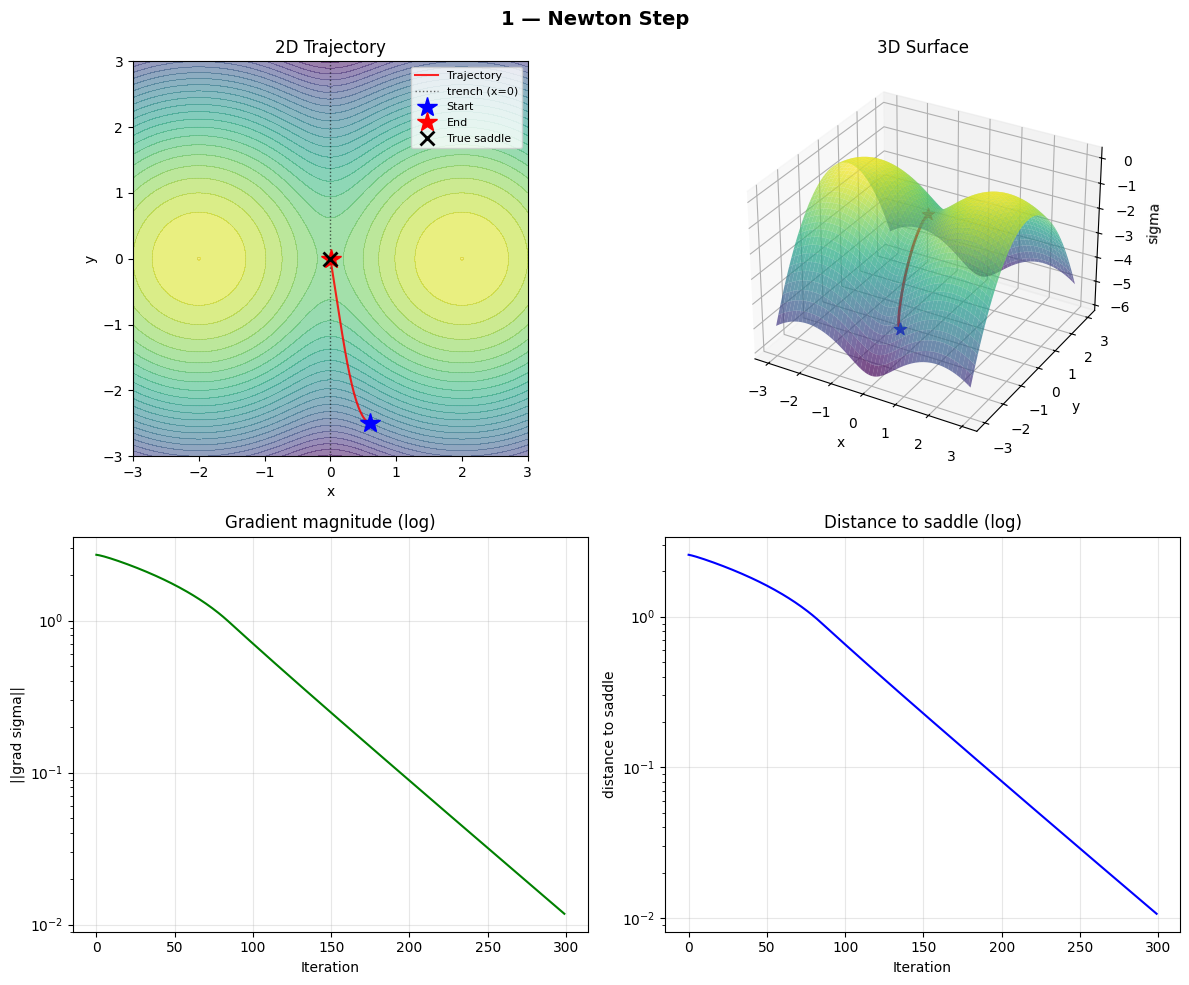

Initial: [ 0.6 -2.5]   Final: [ 0.00232133 -0.01023077]
Final distance to saddle: 0.010706   Final ||grad||: 0.011793


In [14]:
nav_newton = make_nav(NewtonStepper(step_size=0.02, max_step=1.0))
nav_newton.navigate(START_POSITION)
viz.plot(nav_newton, title="1 — Newton Step")

## 2 — Sign-decomposed (first order)

Reaches the trench far sooner, but the gradient-magnitude and distance panels never settle: the
$\mathrm{sign}$ switching **chatters** on the surface.

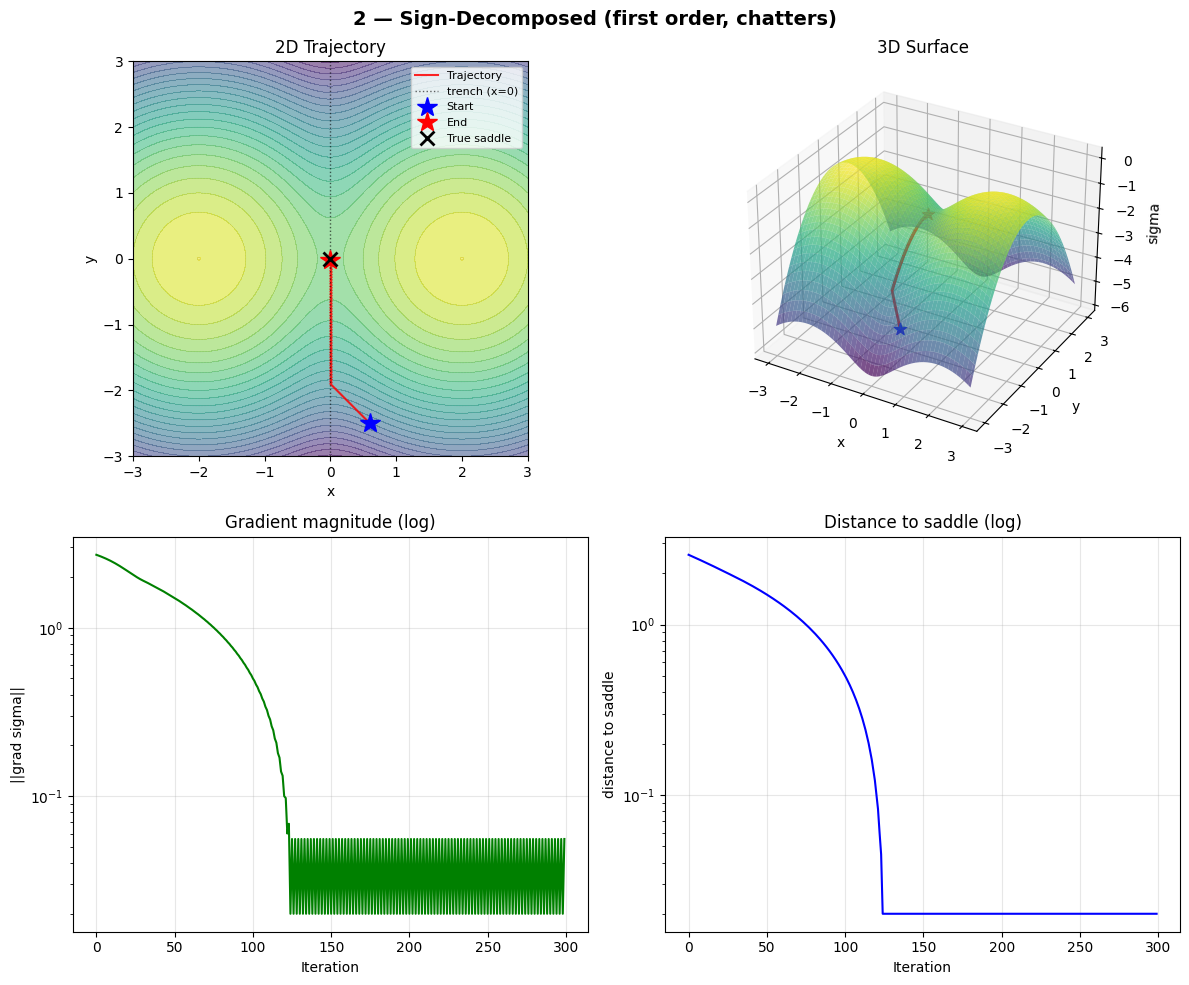

Initial: [ 0.6 -2.5]   Final: [-2.8449465e-16 -2.0000000e-02]
Final distance to saddle: 0.020000   Final ||grad||: 0.055693


In [15]:
nav_sign = make_nav(SignDecomposedStepper(step_size=0.02))
nav_sign.navigate(START_POSITION)
viz.plot(nav_sign, title="2 — Sign-Decomposed (first order, chatters)")

## 3 — Anisotropic Newton  (`gain_perp=0.2`, `gain_along=0.02`)

Smooth exponential snap onto the trench, then a gentle climb. No chatter.

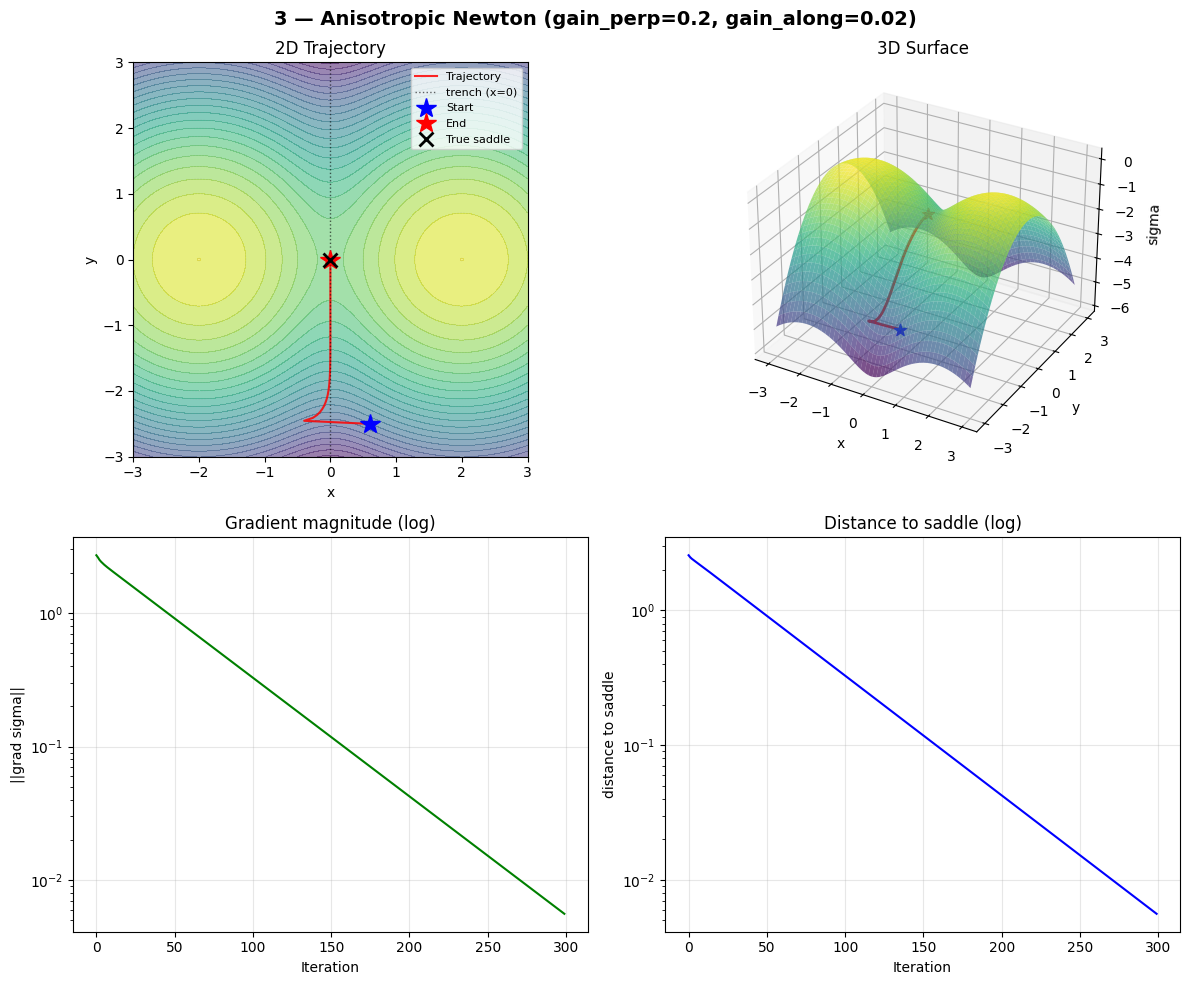

Initial: [ 0.6 -2.5]   Final: [ 0.00043526 -0.00546712]
Final distance to saddle: 0.005597   Final ||grad||: 0.005580


In [16]:
nav_aniso = make_nav(AnisotropicNewtonStepper(gain_perp=0.2, gain_along=0.02))
nav_aniso.navigate(START_POSITION)
viz.plot(nav_aniso, title="3 — Anisotropic Newton (gain_perp=0.2, gain_along=0.02)")

## 4 — Tanh sliding (boundary-layer SMC)

Same snap-then-climb shape, but the across-trench reach speed is bounded and smooth.

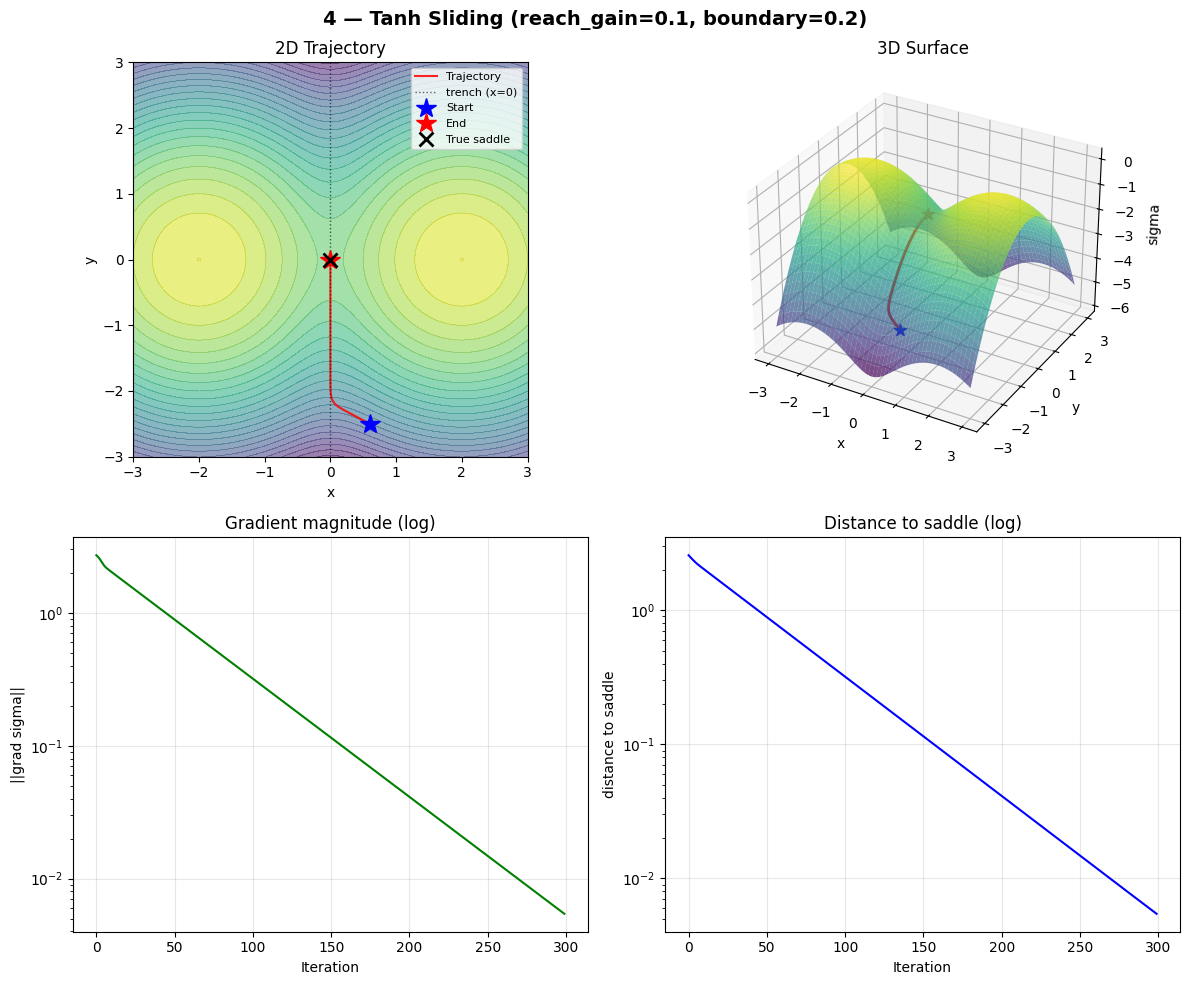

Initial: [ 0.6 -2.5]   Final: [ 0.00043526 -0.00532576]
Final distance to saddle: 0.005453   Final ||grad||: 0.005436


In [17]:
nav_tanh = make_nav(TanhSlidingStepper(reach_gain=0.1, boundary=0.2, gain_along=0.02))
nav_tanh.navigate(START_POSITION)
viz.plot(nav_tanh, title="4 — Tanh Sliding (reach_gain=0.1, boundary=0.2)")

## 5 — Adaptive eigen (self-tuning, single `v_max`)

Same snap-then-climb shape as stages 3-4, but with **no gain tuning** — only `v_max`. Watch the
distance-to-saddle panel: it drops to the estimation floor far faster than the fixed-gain rules,
because the near-saddle behavior is exact Newton.

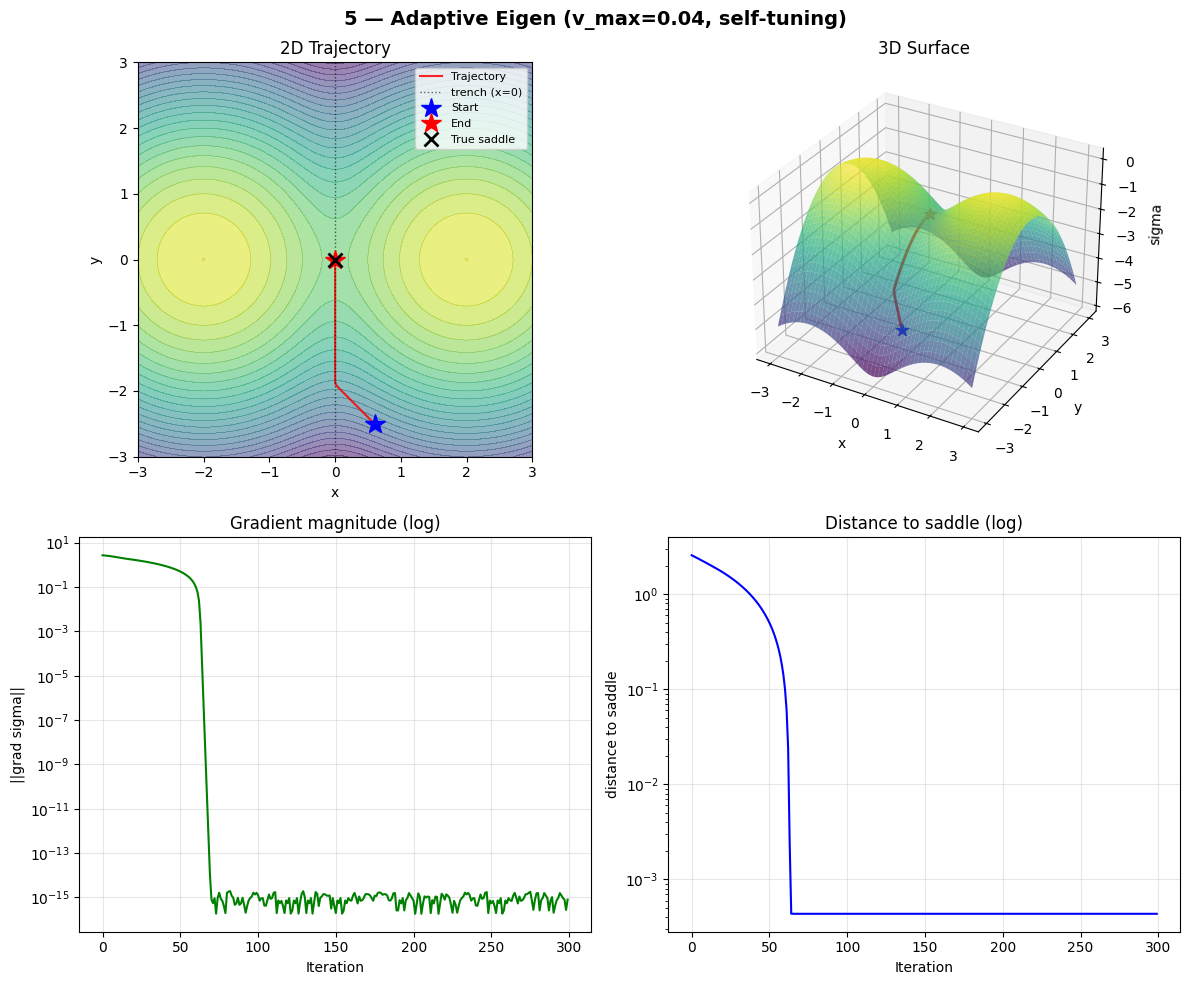

Initial: [ 0.6 -2.5]   Final: [4.35256118e-04 2.88713955e-16]
Final distance to saddle: 0.000435   Final ||grad||: 0.000000


In [18]:
nav_adapt = make_nav(AdaptiveEigenStepper(v_max=0.04))
nav_adapt.navigate(START_POSITION)
viz.plot(nav_adapt, title="5 — Adaptive Eigen (v_max=0.04, self-tuning)")

## 6 - Trench descent: $|\lambda|$ denominator

Case 5's eigenstep is $c_i = -(v_i^T g)/\lambda_i$. Under the local quadratic model $g \approx H r$, the projection $v_i^T g \approx \lambda_i r_i$, so $c_i \approx -r_i$ in *every* eigen-direction. The eigenvalue sign cancels, which is precisely why Newton attracts saddles.

Replace $\lambda_i$ with $|\lambda_i|$. Now
$$c_i = -\frac{\lambda_i r_i}{|\lambda_i|} = -\operatorname{sign}(\lambda_i)\, r_i.$$

* **Perpendicular** ($\lambda > 0$, across trench): $c_\perp \approx -r_\perp$. Same snap to the trench as before.
* **Along trench** ($\lambda < 0$): $c_\parallel \approx +r_\parallel$. The step now points *away* from the saddle along the trench, sliding the formation down toward whatever the trench leads to.

The entire change, in code:

```python
denom = lam if mode == 'signed' else np.abs(lam)   # the entire change
c_i   = -(V[:, i] @ g) / denom[i]
s_i   = v_max * np.tanh(c_i / v_max)
```

This is the Dauphin-style "saddle-free Newton" denominator. The literature uses it to *repel* saddles entirely. Here, we keep the $\tanh$ saturation and use it as a snap-then-descend trench-follower: the perp direction still attracts (snap onto $x=0$), and the along-trench direction now repels (slide down the trench).

**Caveat on this field.** The log-sum-exp trench at $x=0$ has no finite minimum: along $x=0$, $\sigma(0, y) = \log 2 - (4 + y^2)/2$ is maximized at $y=0$ and decreases monotonically as $|y|$ grows. Case 6 demonstrates the sign flip honestly: snap to $x=0$, then slide along the trench until the trajectory leaves the plotted region. The math the rule promises (perp attract, along repel) is what the diagnostic should show; "land at a minimum" is a property of fields with one, not of this rule.

To make the descent direction visible from a near-saddle start, the run uses a small $-y$ nudge so the formation breaks the symmetric tie and slides in one chosen direction, and a smaller iteration count to keep the trajectory on-plot.

In [19]:
class AdaptiveEigenStepperAbs:
    """Case 5 with |lambda_i| in the denominator.

    s_i = v_max * tanh( (-g_i / |lambda_i|) / v_max ),  step = sum_i s_i v_i

    Perp eigen-direction (lambda > 0) : c_perp ~ -r_perp -> snap to trench
    Along eigen-direction (lambda < 0): c_along ~ +r_along -> descend the trench
    Identical to AdaptiveEigenStepper everywhere except the denominator.
    """

    def __init__(self, v_max=0.04):
        self.v_max = v_max

    def compute_step(self, gradient, hessian):
        lam, V = np.linalg.eigh(hessian)
        eps = 1e-9
        if lam[0] * lam[1] >= -eps or np.min(np.abs(lam)) < eps:
            # saddle topology temporarily collapsed: saturate the whole Newton vector
            delta = -np.linalg.pinv(hessian) @ gradient
            n = np.linalg.norm(delta)
            if n > 1e-12:
                return delta * (self.v_max * np.tanh(n / self.v_max) / n)
            return delta
        # Newton eigensteps with |lambda| denominator, then saturate each independently
        denom = np.abs(lam)
        c0 = -(V[:, 0] @ gradient) / denom[0]
        c1 = -(V[:, 1] @ gradient) / denom[1]
        s0 = self.v_max * np.tanh(c0 / self.v_max)
        s1 = self.v_max * np.tanh(c1 / self.v_max)
        return s0 * V[:, 0] + s1 * V[:, 1]

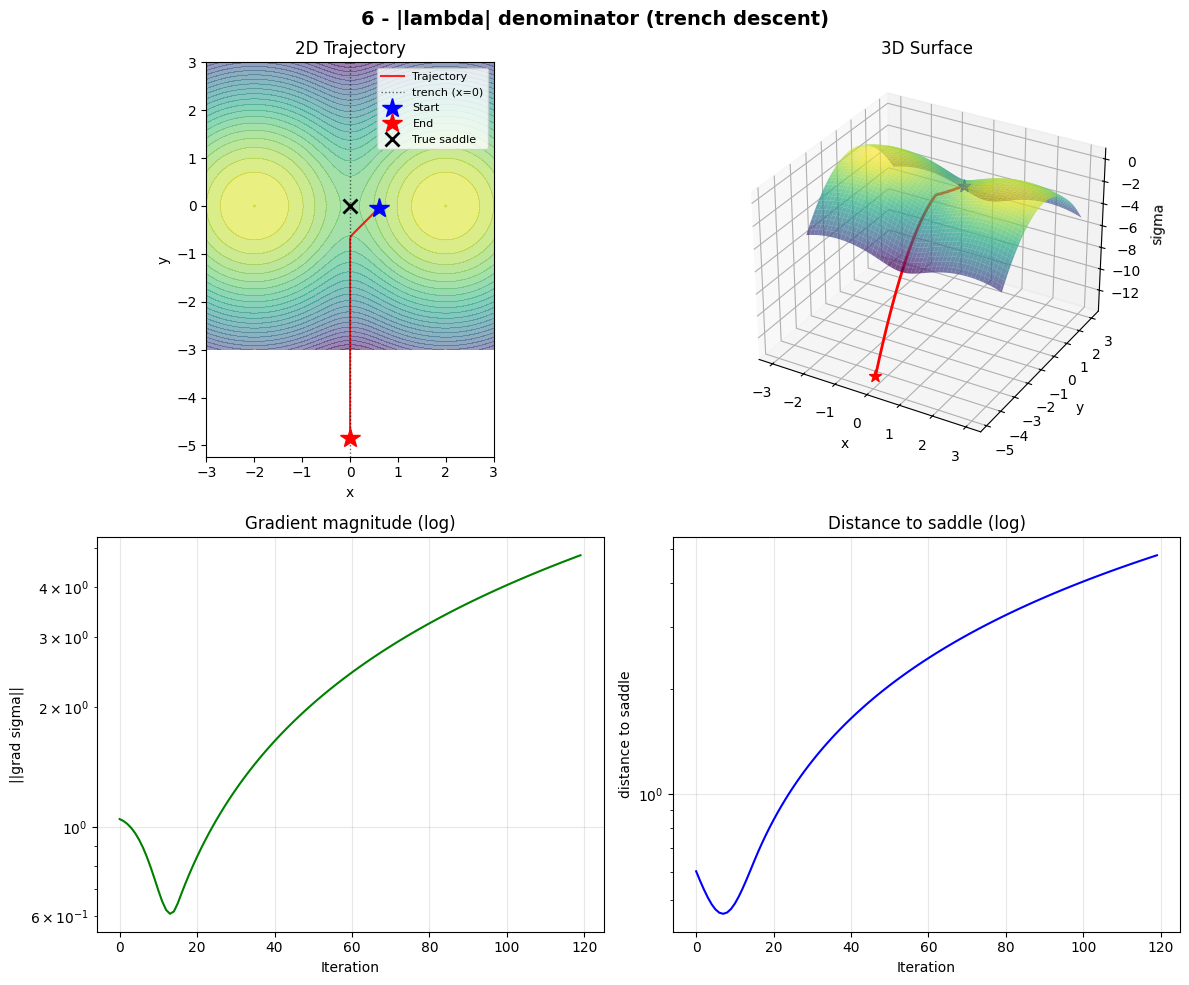

Initial: [ 0.6  -0.05]   Final: [ 4.35256118e-04 -4.84388421e+00]
Final distance to saddle: 4.803884   Final ||grad||: 4.803884


In [20]:
START_POSITION_6 = [0.6, -0.05]            # small -y nudge breaks the symmetric tie
nav_abs = make_nav(AdaptiveEigenStepperAbs(v_max=0.04))
nav_abs.n_iterations = 120                  # trench has no finite minimum; keep on-plot
nav_abs.navigate(START_POSITION_6)
viz.plot(nav_abs, title="6 - |lambda| denominator (trench descent)")

## Side-by-side: the evolution in one figure

Trajectories, across-trench error $|x|$ (the snap), and along-trench error $|y|$ (the climb).
The sign rule's chatter shows up as a filled band; the two smooth rules snap then climb.

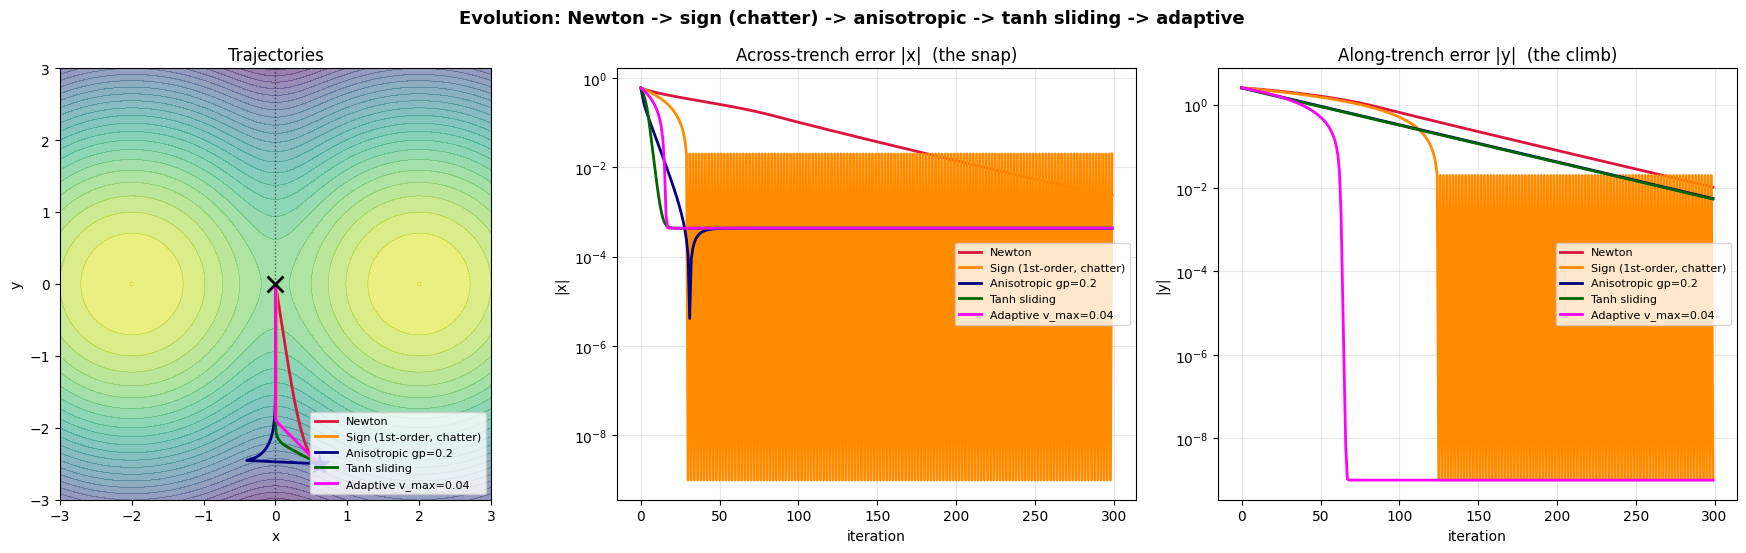

In [21]:
runs = [
    ("Newton",                     NewtonStepper(0.02, 1.0),               "crimson"),
    ("Sign (1st-order, chatter)",  SignDecomposedStepper(0.02),            "darkorange"),
    ("Anisotropic gp=0.2",         AnisotropicNewtonStepper(0.2, 0.02),    "navy"),
    ("Tanh sliding",               TanhSlidingStepper(0.1, 0.2, 0.02),     "darkgreen"),
    ("Adaptive v_max=0.04",        AdaptiveEigenStepper(0.04),             "magenta"),
]
trajs = {}
for name, st, col in runs:
    nav = make_nav(st); nav.navigate(START_POSITION)
    trajs[name] = (np.array(nav.history["centroids"]), col)

fig, ax = plt.subplots(1, 3, figsize=(18, 5.6))
fig.suptitle("Evolution: Newton -> sign (chatter) -> anisotropic -> tanh sliding -> adaptive",
             fontsize=13, fontweight="bold")

field.plot_contour(ax[0]); ax[0].axvline(0, color="k", ls=":", lw=1, alpha=0.6)
for name, (tr, col) in trajs.items():
    ax[0].plot(tr[:, 0], tr[:, 1], lw=2, color=col, label=name)
ax[0].plot(*START_POSITION, "b*", ms=15); ax[0].plot(0, 0, "kx", ms=11, mew=2)
ax[0].set_title("Trajectories"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_aspect("equal"); ax[0].legend(fontsize=8, loc="lower right")

for name, (tr, col) in trajs.items():
    ax[1].semilogy(np.abs(tr[:, 0]) + 1e-9, lw=2, color=col, label=name)
ax[1].set_title("Across-trench error |x|  (the snap)")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("|x|"); ax[1].grid(True, alpha=0.3); ax[1].legend(fontsize=8)

for name, (tr, col) in trajs.items():
    ax[2].semilogy(np.abs(tr[:, 1]) + 1e-9, lw=2, color=col, label=name)
ax[2].set_title("Along-trench error |y|  (the climb)")
ax[2].set_xlabel("iteration"); ax[2].set_ylabel("|y|"); ax[2].grid(True, alpha=0.3); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Takeaways

* The **trench is the positive-eigenvalue eigendirection** of the estimated Hessian; "up the
  trench" is the negative-eigenvalue direction. Classify by the **sign** of the eigenvalue, not its
  magnitude, and never from $\det H$ alone (a scalar can't carry the orientation).
* Plain Newton equalizes both eigen-directions, so it never snaps. Putting a **separate gain on
  each eigen-direction** buys the snap-then-climb behavior while staying smooth, and degenerates to
  Newton when the gains match — so the existing convergence argument extends directly.
* The **sign** rule and the **tanh** rule are the discontinuous and boundary-layer forms of the
  same sliding mode; the tanh form removes the chatter and gives a bounded, physically meaningful
  reach speed. The anisotropic Newton rule is the continuous-feedback cousin (proportional reach
  rather than saturated).
* Snap-back to the trench is exponential at the across-trench gain, independent of progress along
  the trench.
* The **adaptive eigen** rule removes gain tuning entirely: one velocity cap $v_{\max}$ both bounds
  the reach speed and sets the boundary layer, because the Newton normalization $c_i=-g_i/\lambda_i$
  already cancels curvature. Far out it is a bounded snap; near the saddle it is exact Newton with
  superlinear (cubic) convergence, so it reaches the estimation floor in a fraction of the
  iterations the fixed-gain rules need. The cost is that the snap is geometric (it relies on
  starting nearer the trench than the saddle) rather than guaranteed by construction.
* Weighting by **eigenvalue magnitude** is the wrong lever — it slows the low-curvature
  along-trench direction further. Cancel curvature (Newton-normalize), don't reintroduce it.

### Analysis of the Saturated Eigen-Newton Step

The anisotropic and boundary-layer rules of the preceding sections each
require hand-chosen gains. We now remove them, replacing the gain pair with a
single, physically meaningful velocity cap $v_{\max}$ and letting the local
curvature set the step magnitude automatically. The construction applies a
hyperbolic saturation to each eigen-component of the Newton step; the same
$v_{\max}$ then serves two roles at once, bounding the reach speed far from the
saddle and setting the boundary-layer width near it.

Let $\mathbf{g} = \nabla \sigma$ and $\mathbf{H} = \nabla^2 \sigma$ be the
estimated gradient and Hessian at the formation's centroid, and decompose the
(symmetric, at a saddle indefinite) Hessian into its eigenbasis,
$\mathbf{H} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$, with eigenvectors
$\mathbf{v}_i$ and eigenvalues $\lambda_i$. The unconstrained Newton
displacement along each eigen-direction is
%
\begin{equation}
    c_i = -\frac{\mathbf{v}_i^T \mathbf{g}}{\lambda_i}.
\end{equation}
%
Under the local quadratic model $\mathbf{g} \approx \mathbf{H}\,\mathbf{r}$,
where $\mathbf{r}$ is the centroid's displacement from the critical point,
this reduces to $c_i \approx -r_i$: dividing the gradient projection by the
local curvature $\lambda_i$ cancels the curvature and leaves the signed
distance to the critical point along $\mathbf{v}_i$ in position units. Because
the signed eigenvalues are retained, the superposition $\sum_i c_i \mathbf{v}_i
= -\mathbf{H}^{-1}\mathbf{g}$ is exactly the Newton step, so the indefinite
Hessian draws the centroid \emph{toward} the saddle rather than away from it.

To respect the kinematic limits of the formation, we saturate each eigen-step
with a hyperbolic tangent and recombine,
%
\begin{equation}
    s_i = v_{\max}\,\tanh\!\left(\frac{c_i}{v_{\max}}\right),
    \qquad
    \Delta = \sum_{i} s_i\,\mathbf{v}_i.
\end{equation}
%
The single parameter produces an autonomous switch between two regimes. Far
from the saddle, where $|c_i| \gg v_{\max}$, the $\tanh$ saturates and
$s_i \approx v_{\max}\,\operatorname{sign}(c_i)$, yielding a bounded
constant-speed reach in each eigen-direction; $v_{\max}$ here is a true
per-step velocity limit rather than a norm clip. Near the saddle, where
$|c_i| \ll v_{\max}$, the linear approximation $\tanh(x) \approx x$ gives
$s_i \approx c_i$ and recovers the (linearized) Newton step.

The near-saddle convergence rate follows from the next term of the expansion.
Substituting $\tanh z = z - z^3/3 + \mathcal{O}(z^5)$ into the per-direction
update under the local quadratic model gives
%
\begin{equation}
    r_i \;\leftarrow\; r_i + v_{\max}\tanh\!\left(\frac{-r_i}{v_{\max}}\right)
    \;=\; \frac{r_i^{3}}{3\,v_{\max}^{2}} + \mathcal{O}(r_i^{5}),
\end{equation}
%
so the saddle is a cubically attracting fixed point of the saturated map. This
replaces the linear (geometric) decay $r_i \leftarrow (1-\gamma)\,r_i$ of a
fixed-gain rule, eliminating the slow exponential tail once the cap ceases to
bind. We emphasize that this is the convergence of the saturated update under
the local quadratic model, distinct from the quadratic convergence of an
unconstrained Newton iteration: the saturation forgoes the one-step exactness
of Newton on a quadratic---unattainable under a velocity cap---in exchange for
a per-step displacement bounded, for any conditioning of $\mathbf{H}$ and any
distance to the saddle, by $\lVert \Delta \rVert \le \sqrt{n}\,v_{\max}$ (here
$n=2$). This bound is what prevents the overshoot a raw Newton step produces
when the estimated Hessian is poorly conditioned. The saddle is an unstable
equilibrium of the gradient flow rendered attracting by the Newton inversion
$-\mathbf{H}^{-1}\mathbf{g}$; a formal region-of-attraction argument is
treated separately.

Unlike the anisotropic and boundary-layer rules, this construction applies the
same cap to both eigen-directions and so does not impose a gentler rate along
the trench. The preferential collapse onto the trench is then a consequence of
the approach geometry, $|c_\perp| < |c_\parallel|$, rather than of an imposed
gain asymmetry---the price of removing the gains.

Two contrasts clarify the choice of lever. Weighting each eigen-direction by
$|\lambda_i|$, the natural curvature-aware heuristic, does the opposite of what
is wanted: it accelerates the stiff across-trench direction and further slows
the soft along-trench one. The curvature normalization $c_i = -g_i/\lambda_i$
instead cancels curvature, which is what makes a single uniform cap appropriate
across directions of very different stiffness. The signed eigenvalues retained
here also distinguish this rule from the saddle-free Newton step
\cite{dauphin2014}, which substitutes $|\lambda_i|$ to repel saddles; we keep
the sign precisely so that the indefinite Hessian attracts the formation to
the saddle.